---
#### **라이브러리 import 및 데이터 로드**
- Pandas, Numpy 라이브러리 import
- 수정주가, 시가총액 데이터 불러오기

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from module import make_ff_factors, performance_metrics

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [30]:
mkt_cap             = pd.read_csv('../../00_input/KOSPI_KOSDAQ_mkt_cap.csv', index_col='Date', parse_dates=True)
sales_df            = pd.read_csv('../../00_input/KOSPI_KOSDAQ_sales.csv', index_col='Date', parse_dates=True)
adj_close_df        = pd.read_csv('../../00_input/KOSPI_KOSDAQ_adj_close.csv', index_col='Date', parse_dates=True)
factors             = pd.read_csv('../../00_input/Factors.csv', index_col='Date', parse_dates=True)
total_adj_close     = pd.read_csv('../../00_input/KOSPI_KOSDAQ_total_adj_close.csv', index_col='Date', parse_dates=True)
trading_value_60    = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value_60.csv', index_col='Date', parse_dates=True)
trading_value       = pd.read_csv('../../00_input/KOSPI_KOSDAQ_trading_value.csv', index_col='Date', parse_dates=True)

In [31]:
# 월말 수정주가, 월말 시가총액
price_m    = adj_close_df.resample('ME').last()
mkt_cap_m  = mkt_cap.resample('ME').last()

# 5년 = 60개월 lookback
MONTHS_5Y = 60

# CEI_i,t = log(ME_i,t / ME_i,t-5) − log(P_i,t / P_i,t-5)
#        = log(ME_t) - log(ME_t_5) - log(P_t) + log(P_t_5)
log_ME_t   = np.log(mkt_cap_m.replace(0, np.nan))
log_ME_t_5 = np.log(mkt_cap_m.shift(MONTHS_5Y).replace(0, np.nan))
log_P_t    = np.log(price_m.replace(0, np.nan))
log_P_t_5  = np.log(price_m.shift(MONTHS_5Y).replace(0, np.nan))

cei_df = (log_ME_t - log_ME_t_5) - (log_P_t - log_P_t_5)

# 유효한 시점만 사용: 5년 전 데이터가 있는 월말부터
factor_df = cei_df.loc[cei_df.index[MONTHS_5Y]:]

# 결과: index=월말 날짜, columns=종목, values=CEI
# cei_df

In [32]:
# 월간 데이터 계산
monthly_rets        = total_adj_close.resample('ME').last().pct_change(fill_method=None)

# 수익률 윈저라이징
monthly_rets_wins = monthly_rets.clip(
    lower=monthly_rets.quantile(0.01),
    upper=monthly_rets.quantile(0.99),
    axis=1
)

In [33]:
# 일별 수익률과 거래대금을 이용해 Amihud illiquidity 계산
daily_ret        = adj_close_df.pct_change(fill_method=None)
daily_illiq      = (daily_ret.abs()/trading_value)
illiq            = daily_illiq.resample('ME').mean()

In [79]:
# 백테스트 기간을 설정하여 월말 날짜 리스트 생성
start_point = '2014-12-31'
end_point   = '2026-02-28'

month_ends  = pd.date_range(start=start_point, end=end_point, freq='ME')

In [80]:
# 종목 수 선정
n                      = 20  

# 가중방식 선택
weight_method_temp     = "Cap"  # ['Equal'(동일가중), Cap'(시가총액가중)]

# 유동성 하위 종목 제외
trading_threshold      = 0.10     # 유동성 하위 종목 제외

# 거래대금 설정
high_cost              = 0.008    # 80bp
low_cost               = 0.003    # 30bp
illiq_threshold        = 0.80     # Amihud 유동성 기준 상위 20%

portfolio_return       = pd.Series(dtype=float)
total_trade            = pd.Series(dtype=float)

initial_NAV            = 1        # 초기값
NAV                    = initial_NAV

In [81]:
portfolio_return = pd.Series(index=month_ends, dtype=float)
total_trade      = pd.Series(index=month_ends, dtype=float)
prev_portfolio   = pd.Series(dtype=float)

portfolio_return[month_ends[0]] = 0.0
NAV = initial_NAV

In [82]:
for i in range(len(month_ends) - 1):

    # 매기간 날짜 업데이트
    start_date  = month_ends[i]
    end_date    = month_ends[i + 1]

    # 거래대금 하위 종목 제외
    trading_today      = trading_value_60.loc[start_date].dropna()
    filtered           = trading_today[trading_today > trading_today.quantile(trading_threshold)].index

    factor_filtered    = factor_df.loc[start_date, filtered].dropna()

    # 종목 선정
    basket = factor_filtered.nsmallest(n).index

    # 유동성 반영
    illiq_startdate = illiq.loc[start_date].dropna()
    threshold       = illiq_startdate.quantile(illiq_threshold)
    illiquid_top20  = illiq_startdate[illiq_startdate >= threshold].index

    # 가중방식 선택
    prev_weights   = prev_portfolio / prev_portfolio.sum()
    
    # 동일가중
    if weight_method_temp == 'Equal':
        target_weights = pd.Series(1.0/len(basket), index=basket)

    # 시가총액가중
    else:
        cap = mkt_cap.loc[start_date, basket]
        target_weights = cap/cap.sum()

    # 거래비용 반영
    all_index = target_weights.index.union(prev_weights.index)
    target_w = target_weights.reindex(all_index, fill_value=0)
    prev_w   = prev_weights.reindex(all_index, fill_value=0)

    delta_w   = target_w - prev_w
    trade_amounts = abs(delta_w) * NAV
    cost_rate = np.where(delta_w.index.isin(illiquid_top20), high_cost, low_cost)

    trade_cost = (trade_amounts * cost_rate).sum()

    NAV_new = NAV - trade_cost
    
    current_portfolio_value = target_weights * NAV_new

    # 당기 포트폴리오 최종 가치 계산
    ret_seg              = monthly_rets_wins.loc[end_date, basket]
    next_portfolio_value = current_portfolio_value * (ret_seg + 1)

    # 당기 포트폴리오 수익률 계산
    NAV_new       = next_portfolio_value.sum()
    portfolio_ret = NAV_new / NAV - 1

    # prev_portfolio 업데이트
    prev_portfolio = next_portfolio_value

    # NAV 업데이트
    NAV = NAV_new

    # 총 거래금액 저장
    total_trade.loc[start_date] = trade_amounts.sum()
    
    # 포트폴리오 수익률 저장
    portfolio_return.loc[end_date] = portfolio_ret

In [83]:
portfolio_NAV = (1 + portfolio_return).cumprod() * initial_NAV

In [84]:
# Portfolio 데이터 생성
df = pd.concat(
    [portfolio_return, portfolio_NAV, total_trade], 
    axis=1
)

df.columns = ["Return", "NAV", "Trade"]
df.index.name = "Date"

# 초기값 저장
df.loc[df.index[0], "NAV"] = initial_NAV

portfolio = df

In [85]:
factors_monthly = make_ff_factors(factors)[:-1]

In [86]:
# 1. 두 데이터 공통 구간 맞추기
df = pd.concat([df['Return'], factors_monthly], axis=1, join="inner").dropna()

In [87]:
# 2. 종속변수: 포트폴리오 초과수익률
y = df['Return'] - df['RF']

# 3. 독립변수: MKT, SMB, HML, MOM
X = pd.DataFrame({
    "MKT": df['KOSPI'] - df['RF'],
    "SMB": df['SMB'],
    "HML": df['HML'],
    "MOM": df['MOM']
}, index=df.index)

X = sm.add_constant(X, has_constant='add')

# 4. OLS 회귀
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags":12})  # Newey-West 표준오차

In [88]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.535
Method:                 Least Squares   F-statistic:                     29.58
Date:                Wed, 18 Mar 2026   Prob (F-statistic):           1.73e-17
Time:                        19:24:27   Log-Likelihood:                 244.93
No. Observations:                 135   AIC:                            -479.9
Df Residuals:                     130   BIC:                            -465.3
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0028      0.003     -0.852      0.3

In [89]:
metrics = performance_metrics(portfolio)

In [90]:
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

CAGR: 0.0453
Volatility (ann.): 0.2051
Sharpe Ratio: 0.3156
MDD: -0.5945
Average Turnover (monthly): 0.2044


In [91]:
df_ret = pd.concat([portfolio['Return'].dropna(), factors_monthly['KOSPI']], axis=1, join='inner')
df_ret.columns = ['Portfolio', 'KOSPI']
df_ret.index.name = 'Date'

In [92]:
df_nav = (1 + df_ret).cumprod()
df_nav.columns = ['Portfolio', 'KOSPI']

<Axes: xlabel='Date'>

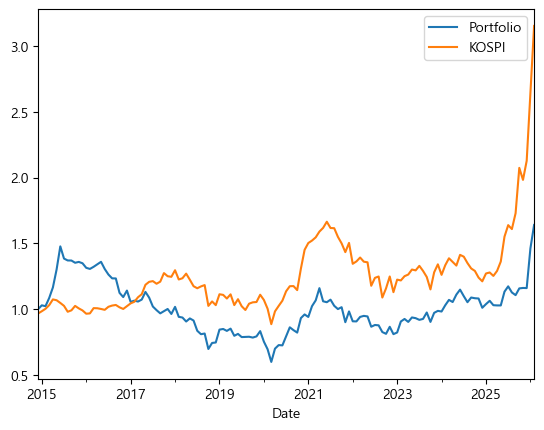

In [93]:
df_nav.plot()

<Axes: xlabel='Date'>

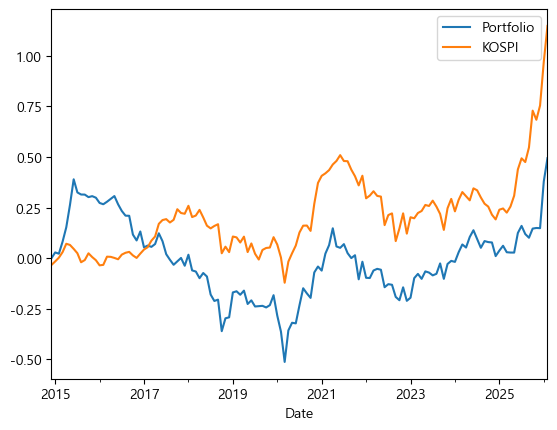

In [94]:
np.log1p(df_ret).cumsum().plot()